# UTS Data Mining: Klasifikasi Kualitas Anggur
Pada notebook ini, saya mengerjakan dimulai dengan membangun model klasifikasi untuk memprediksi nilai `quality` pada dataset wine quality. Dataset ini berisi beberapa fitur kimiawi anggur, seperti kadar asam, gula, sulfur dioxide, pH, sulphates, alcohol, dan fitur lainnya.

Tujuan utama dari analisis ini adalah membuat model yang dapat mempelajari pola dari data training, kemudian menggunakan model tersebut untuk memprediksi kualitas anggur pada data testing.

Tahapan yang akan saya lakukan dalam notebook ini adalah:

1. Melakukan persiapan data  
2. Melakukan eksplorasi data awal  
3. Melakukan pembersihan data  
4. Memeriksa kebutuhan feature scaling  
5. Membuat beberapa model klasifikasi  
6. Mengevaluasi model menggunakan akurasi, classification report, dan confusion matrix  
7. Memilih model terbaik  
8. Menyimpan model  
9. Menerapkan model pada data testing  
10. Menyimpan hasil prediksi dalam format CSV  



## 1. Import Library

Langkah pertama adalah mengimpor library yang diperlukan. Library `pandas` dan `numpy` digunakan untuk mengolah data, sedangkan `matplotlib` dan `seaborn` digunakan untuk visualisasi. Untuk proses machine learning, saya menggunakan beberapa fungsi dan model dari `scikit-learn`. Selain itu, menggunakan `joblib` untuk menyimpan model yang sudah dilatih.


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier

import joblib
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

## 2. Persiapan Data

Pada tahap persiapan data, membaca dataset training dan dataset testing menggunakan `pandas`. Dataset training digunakan untuk melatih model karena di dalamnya terdapat kolom target `quality`. Sementara itu, dataset testing tidak memiliki kolom `quality`, sehingga nantinya nilai kualitas pada data testing harus diprediksi menggunakan model yang sudah dibuat.


In [2]:
# Membaca dataset
data_train = pd.read_csv("data_training.csv")
data_test = pd.read_csv("data_testing.csv")

print("Ukuran data training:", data_train.shape)
print("Ukuran data testing:", data_test.shape)

Ukuran data training: (857, 13)
Ukuran data testing: (286, 12)


In [3]:
# Menampilkan 5 data pertama pada data training
data_train.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8,5,1366
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2,5,103
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0,7,942
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9,6,811
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0,6,918


In [4]:
# Menampilkan 5 data pertama pada data testing
data_test.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Id
0,6.8,0.61,0.04,1.5,0.057,5.0,10.0,0.99525,3.42,0.60,9.500000,222
1,6.9,0.84,0.21,4.1,0.074,16.0,65.0,0.99842,3.53,0.72,9.233333,1514
2,7.0,0.58,0.12,1.9,0.091,34.0,124.0,0.99560,3.44,0.48,10.500000,417
3,7.8,0.48,0.68,1.7,0.415,14.0,32.0,0.99656,3.09,1.06,9.100000,754
4,12.5,0.60,0.49,4.3,0.100,5.0,14.0,1.00100,3.25,0.74,11.900000,516


### Interpretasi Persiapan Data

Dari hasil pembacaan data, terlihat bahwa data training memiliki kolom `quality` yang berfungsi sebagai target atau label yang akan diprediksi. Data testing tidak memiliki kolom `quality`, sehingga data ini digunakan sebagai data uji akhir.

Kolom `Id` hanya digunakan sebagai identitas setiap baris data. Oleh karena itu, tidak menggunakan kolom `Id` sebagai fitur model karena kolom tersebut tidak menjelaskan karakteristik kimiawi anggur.


## 3. Eksplorasi Data Awal

Setelah data berhasil dibaca, saya melakukan eksplorasi data awal. Tujuannya adalah untuk memahami struktur dataset, tipe data setiap kolom, statistik deskriptif, serta distribusi target `quality`. Tahap ini penting karena sebelum membuat model, perlu memahami kondisi data yang digunakan.


In [5]:
# Informasi struktur data training
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 857 entries, 0 to 856
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         857 non-null    float64
 1   volatile acidity      857 non-null    float64
 2   citric acid           857 non-null    float64
 3   residual sugar        857 non-null    float64
 4   chlorides             857 non-null    float64
 5   free sulfur dioxide   857 non-null    float64
 6   total sulfur dioxide  857 non-null    float64
 7   density               857 non-null    float64
 8   pH                    857 non-null    float64
 9   sulphates             857 non-null    float64
 10  alcohol               857 non-null    float64
 11  quality               857 non-null    int64  
 12  Id                    857 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 87.2 KB


In [6]:
# Informasi struktur data testing
data_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 286 entries, 0 to 285
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         286 non-null    float64
 1   volatile acidity      286 non-null    float64
 2   citric acid           286 non-null    float64
 3   residual sugar        286 non-null    float64
 4   chlorides             286 non-null    float64
 5   free sulfur dioxide   286 non-null    float64
 6   total sulfur dioxide  286 non-null    float64
 7   density               286 non-null    float64
 8   pH                    286 non-null    float64
 9   sulphates             286 non-null    float64
 10  alcohol               286 non-null    float64
 11  Id                    286 non-null    int64  
dtypes: float64(11), int64(1)
memory usage: 26.9 KB


In [7]:
# Statistik deskriptif data training
data_train.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000
mean,8.261960,0.529393,0.267351,2.506184,0.086830,15.782964,45.978413,0.996692,3.313092,0.656709,10.430338,5.653442,813.749125
std,1.701992,0.179162,0.195144,1.293512,0.048721,10.300402,31.692113,0.001901,0.152079,0.167364,1.066971,0.821777,463.807063
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.390000,8.400000,3.000000,0.000000
25%,7.100000,0.395000,0.090000,1.900000,0.070000,7.000000,21.000000,0.995520,3.210000,0.550000,9.500000,5.000000,413.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,14.000000,38.000000,0.996680,3.310000,0.620000,10.200000,6.000000,814.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,63.000000,0.997800,3.400000,0.730000,11.100000,6.000000,1214.000000
max,15.600000,1.580000,1.000000,15.500000,0.611000,68.000000,278.000000,1.003200,4.010000,2.000000,14.000000,8.000000,1597.000000


In [8]:
# Melihat nama-nama kolom pada data training
print(data_train.columns.tolist())

['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'Id']


### Distribusi Target `Quality'
Selanjutnya melihat distribusi target `Quality` untuk mengetahui jumlah data pada setiap kelas kualitas anggur. Hal ini penting karena jika jumlah data pada setiap kelas tidak seimbang, model dapat cenderung lebih sering memprediksi kelas yang jumlah datanya paling banyak.


In [9]:
# Distribusi kelas quality
distribusi_quality = data_train["quality"].value_counts().sort_index()
distribusi_quality

,count
quality,
3,6
4,26
5,362
6,341
7,109
8,13


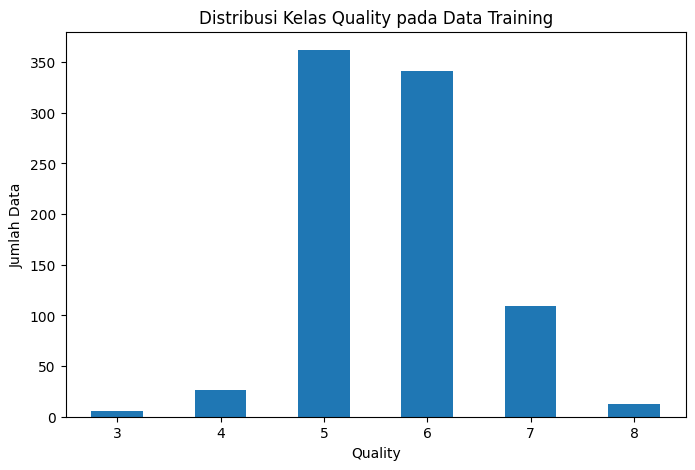

In [10]:
plt.figure(figsize=(8, 5))
distribusi_quality.plot(kind="bar")
plt.title("Distribusi Kelas Quality pada Data Training")
plt.xlabel("Quality")
plt.ylabel("Jumlah Data")
plt.xticks(rotation=0)
plt.show()

### Interpretasi Distribusi Target

Berdasarkan grafik distribusi `quality`, dapat dilihat bahwa jumlah data pada setiap kelas tidak sama. Beberapa nilai kualitas memiliki jumlah data yang lebih banyak dibandingkan kelas lainnya. Kondisi seperti ini cukup wajar pada kasus klasifikasi kualitas produk, karena biasanya sebagian besar sampel berada pada kualitas sedang, sedangkan kualitas yang sangat rendah atau sangat tinggi jumlahnya lebih sedikit.


## 4. Pembersihan Data

Pada tahap pembersihan data, saya memastikan bahwa data yang digunakan sudah layak untuk proses pemodelan. Pemeriksaan yang saya lakukan meliputi pengecekan missing value dan data duplikat. Jika ditemukan masalah pada data, maka perlu dilakukan penanganan terlebih dahulu sebelum model dibuat.


In [11]:
# Mengecek missing value pada data training
data_train.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [12]:
# Mengecek missing value pada data testing
data_test.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [13]:
print("Total missing value data training:", data_train.isnull().sum().sum())
print("Total missing value data testing:", data_test.isnull().sum().sum())

Total missing value data training: 0
Total missing value data testing: 0


### Interpretasi Missing Value

Berdasarkan hasil pengecekan, total missing value bernilai 0, maka artinya tidak ada data kosong pada dataset training maupun testing. Dengan demikian,  tidak diperlukan penghapusan baris data.

In [14]:
# Mengecek data duplikat
print("Jumlah data duplikat pada training:", data_train.duplicated().sum())
print("Jumlah data duplikat pada testing:", data_test.duplicated().sum())

Jumlah data duplikat pada training: 0
Jumlah data duplikat pada testing: 0


### Interpretasi Data Duplikat

Saya melakukan pemeriksaan data duplikat untuk mengetahui apakah terdapat baris data yang sama persis. Pada data training, data duplikat dapat dipertimbangkan untuk dihapus jika memang benar-benar sama dan tidak diperlukan. Namun, pada data testing, saya tidak menghapus baris sembarangan karena setiap `Id` harus tetap mendapatkan hasil prediksi.


## 5. Pemeriksaan Skala Fitur

Setelah data dibersihkan, saya memeriksa skala fitur. Beberapa model seperti KNN, SVM, dan Logistic Regression cukup sensitif terhadap perbedaan skala data. Oleh karena itu, diperlukan untuk melihat apakah terdapat fitur yang memiliki rentang nilai jauh berbeda dibandingkan fitur lain.


In [15]:
fitur_kimia = data_train.drop(columns=["quality", "Id"])
fitur_kimia.describe().T[["min", "max", "mean", "std"]]

,min,max,mean,std
fixed acidity,4.60000,15.6000,8.261960,1.701992
volatile acidity,0.12000,1.5800,0.529393,0.179162
citric acid,0.00000,1.0000,0.267351,0.195144
residual sugar,0.90000,15.5000,2.506184,1.293512
chlorides,0.01200,0.6110,0.086830,0.048721
free sulfur dioxide,1.00000,68.0000,15.782964,10.300402
total sulfur dioxide,6.00000,278.0000,45.978413,31.692113
density,0.99007,1.0032,0.996692,0.001901
pH,2.74000,4.0100,3.313092,0.152079
sulphates,0.39000,2.0000,0.656709,0.167364


### Interpretasi Skala Fitur

Berdasarkan statistik deskriptif, dapat dilihat bahwa beberapa fitur memiliki skala yang berbeda. Misalnya, `total sulfur dioxide` memiliki rentang nilai yang lebih besar dibandingkan `density` atau `chlorides`. Perbedaan skala ini dapat memengaruhi model yang berbasis jarak atau perhitungan koefisien.

Oleh karena itu, untuk model seperti Logistic Regression, KNN, dan SVM, saya menggunakan `StandardScaler`. Sementara itu, untuk model berbasis pohon seperti Random Forest dan Extra Trees, scaling tidak wajib karena model tersebut bekerja berdasarkan percabangan keputusan, bukan berdasarkan jarak antar data.


## 6. Pemisahan Fitur dan Target

Pada tahap ini, saya memisahkan data menjadi fitur `X` dan target `y`. Kolom `quality` digunakan sebagai target karena nilai inilah yang ingin diprediksi. Kolom `Id` tidak saya gunakan sebagai fitur karena hanya berfungsi sebagai nomor identitas data.


In [16]:
X = data_train.drop(columns=["quality", "Id"])
y = data_train["quality"]

X_test = data_test.drop(columns=["Id"])
test_id = data_test["Id"]

print("Ukuran X:", X.shape)
print("Ukuran y:", y.shape)
print("Ukuran X_test:", X_test.shape)

Ukuran X: (857, 11)
Ukuran y: (857,)
Ukuran X_test: (286, 11)


### Interpretasi Pemisahan Data

Variabel `X` berisi fitur-fitur kimiawi anggur yang digunakan untuk memprediksi kualitas. Variabel `y` berisi nilai `quality` sebagai kelas target. Untuk data testing, saya menyimpan kolom `Id` secara terpisah karena kolom tersebut akan digunakan kembali saat membuat file hasil prediksi akhir.


## 7. Pembagian Data Training dan Validasi

Sebelum model digunakan untuk memprediksi data testing, saya membagi data training menjadi data latih dan data validasi. Data latih digunakan untuk melatih model, sedangkan data validasi digunakan untuk mengevaluasi kemampuan model pada data yang belum pernah dilihat saat proses pelatihan.


In [17]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

X_train: (685, 11)
X_val: (172, 11)
y_train: (685,)
y_val: (172,)


### Interpretasi Pembagian Data

Saya membagi data dengan proporsi 80% untuk training dan 20% untuk validasi. Parameter `stratify=y` digunakan agar distribusi kelas `quality` pada data training dan validasi tetap proporsional. Dengan cara ini, proses evaluasi menjadi lebih adil karena setiap kelas tetap terwakili.


## 8. Pembuatan Beberapa Model Klasifikasi

Pada tahap ini, saya mencoba beberapa model klasifikasi agar dapat membandingkan performanya. Model yang saya gunakan adalah Logistic Regression, KNN, SVM, Random Forest, Extra Trees, dan Gradient Boosting. Saya tidak langsung memilih satu model di awal karena setiap model memiliki karakteristik yang berbeda dan hasilnya perlu dibandingkan berdasarkan evaluasi.


In [18]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=5000, class_weight="balanced"))
    ]),

    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ]),

    "SVM RBF": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(C=3, gamma="scale", class_weight="balanced"))
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=500,
        random_state=42,
        class_weight="balanced",
        max_features="sqrt"
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=700,
        random_state=42,
        class_weight="balanced",
        max_features="sqrt"
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

## 9. Evaluasi Awal Menggunakan Data Validasi

Setiap model dilatih menggunakan data training, diuji menggunakan data validasi. Metrik utama yang digunakan adalah akurasi, yaitu perbandingan antara jumlah prediksi yang benar dengan seluruh data validasi.


In [19]:
hasil_validasi = []

for nama_model, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    acc = accuracy_score(y_val, y_pred)

    hasil_validasi.append({
        "Model": nama_model,
        "Akurasi Validasi": acc
    })

hasil_validasi_df = pd.DataFrame(hasil_validasi).sort_values(by="Akurasi Validasi", ascending=False)
hasil_validasi_df

,Model,Akurasi Validasi
5,Gradient Boosting,0.622093
3,Random Forest,0.598837
4,Extra Trees,0.593023
2,SVM RBF,0.494186
1,KNN,0.482558
0,Logistic Regression,0.377907


## 10. Evaluasi Menggunakan Cross Validation

Selain evaluasi dengan satu kali pembagian training-validasi, saya juga menggunakan 5-fold cross validation. Cross validation digunakan agar hasil evaluasi lebih stabil, karena model diuji pada beberapa pembagian data yang berbeda. Dengan demikian, penilaian performa model tidak hanya bergantung pada satu pembagian data saja.


In [20]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

hasil_cv = []

for nama_model, model in models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")

    hasil_cv.append({
        "Model": nama_model,
        "Rata-rata Akurasi CV": scores.mean(),
        "Standar Deviasi": scores.std()
    })

hasil_cv_df = pd.DataFrame(hasil_cv).sort_values(by="Rata-rata Akurasi CV", ascending=False)
hasil_cv_df

,Model,Rata-rata Akurasi CV,Standar Deviasi
3,Random Forest,0.646491,0.034422
4,Extra Trees,0.638263,0.033361
5,Gradient Boosting,0.607942,0.013718
1,KNN,0.556691,0.060438
2,SVM RBF,0.525099,0.027512
0,Logistic Regression,0.428227,0.039363


### Interpretasi Evaluasi Model

Model terbaik saya pilih berdasarkan hasil evaluasi, terutama nilai rata-rata akurasi cross validation. Semakin tinggi nilai akurasi, semakin baik kemampuan model dalam memprediksi kelas `quality`.

Saya menggunakan cross validation karena metode ini memberikan gambaran performa model yang lebih stabil dibandingkan hanya menggunakan satu kali pembagian data training dan validasi.


## 11. Pemilihan Model Terbaik

Setelah semua model dievaluasi, saya memilih model terbaik berdasarkan rata-rata akurasi cross validation tertinggi. Model inilah yang kemudian digunakan untuk tahap evaluasi lebih lanjut dan prediksi data testing.


In [21]:
best_model_name = hasil_cv_df.iloc[0]["Model"]
best_model = models[best_model_name]

print("Model terbaik berdasarkan cross validation:", best_model_name)
print("Rata-rata akurasi CV:", hasil_cv_df.iloc[0]["Rata-rata Akurasi CV"])

Model terbaik berdasarkan cross validation: Random Forest
Rata-rata akurasi CV: 0.6464912280701756


## 12. Evaluasi Detail Model Terbaik

Setelah mendapatkan model terbaik yaitu Random Forest, saya melatih kembali model tersebut pada data training hasil split, lalu mengevaluasinya menggunakan data validasi. Evaluasi dilakukan dengan akurasi, classification report, dan confusion matrix agar performa model dapat dilihat secara lebih detail.


In [22]:
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_val)

print("Akurasi validasi model terbaik:", accuracy_score(y_val, y_pred_best))
print("\nClassification Report:")
print(classification_report(y_val, y_pred_best))

Akurasi validasi model terbaik: 0.5988372093023255

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         5
           5       0.67      0.77      0.71        73
           6       0.55      0.60      0.57        68
           7       0.45      0.23      0.30        22
           8       1.00      0.33      0.50         3

    accuracy                           0.60       172
   macro avg       0.44      0.32      0.35       172
weighted avg       0.57      0.60      0.58       172



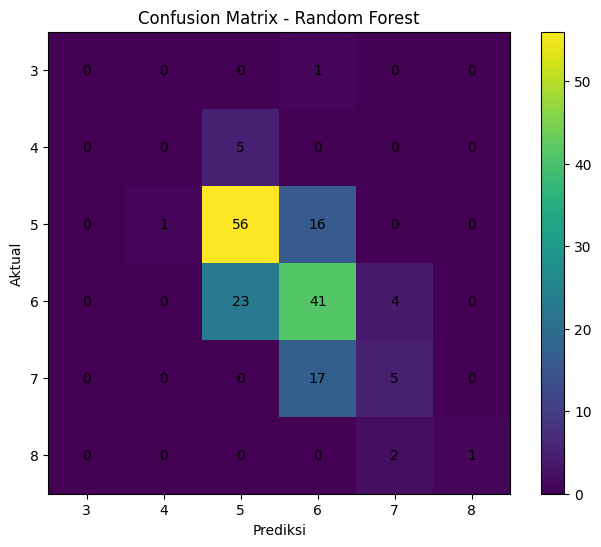

In [23]:
cm = confusion_matrix(y_val, y_pred_best)

plt.figure(figsize=(8, 6))
plt.imshow(cm)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.colorbar()

labels = sorted(y.unique())
plt.xticks(range(len(labels)), labels)
plt.yticks(range(len(labels)), labels)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

### Interpretasi Confusion Matrix

Berdasarkan confusion matrix, model Random Forest paling banyak memprediksi dengan benar pada kelas `quality` 5 dan 6. Pada kelas aktual 5, sebanyak 56 data berhasil diprediksi dengan benar, sedangkan 16 data diprediksi sebagai kelas 6. Pada kelas aktual 6, sebanyak 41 data berhasil diprediksi dengan benar, tetapi masih terdapat beberapa data yang tertukar ke kelas 5 dan 7.

Model terlihat lebih baik dalam mengenali kelas dengan jumlah data yang dominan, yaitu kelas 5 dan 6. Sementara itu, kelas dengan jumlah data yang lebih sedikit seperti 3, 4, 7, dan 8 masih lebih sulit diprediksi secara tepat. Hal ini menunjukkan bahwa ketidakseimbangan distribusi target dapat memengaruhi performa model pada masing-masing kelas.

## 13. Feature Importance

Model terbaik yang terpilih merupakan model berbasis pohon, saya dapat melihat feature importance. Feature importance digunakan untuk mengetahui fitur mana yang paling berpengaruh dalam proses prediksi `quality`.


,Fitur,Importance
1,volatile acidity,0.148582
9,sulphates,0.122203
10,alcohol,0.113528
6,total sulfur dioxide,0.095778
2,citric acid,0.088421
4,chlorides,0.081224
7,density,0.078284
8,pH,0.077015
5,free sulfur dioxide,0.069459
0,fixed acidity,0.066461


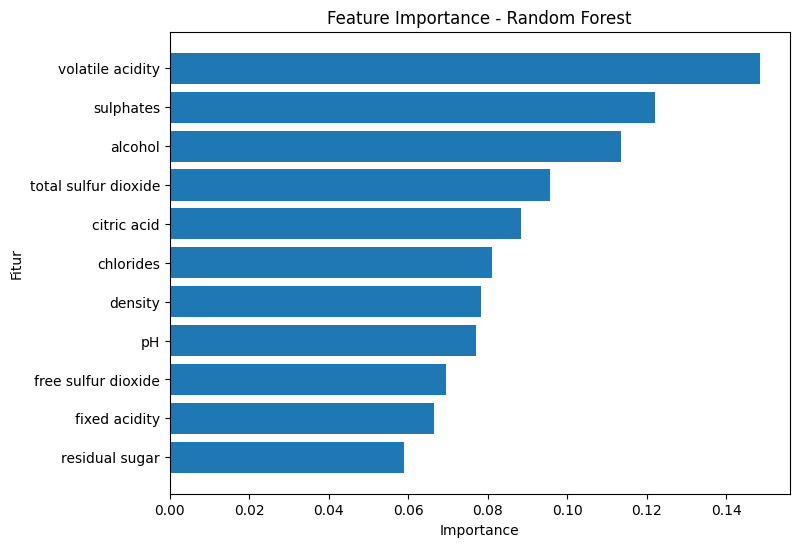

In [24]:
# Menampilkan feature importance jika model memiliki atribut feature_importances_
model_untuk_importance = best_model

# Jika best_model adalah Pipeline, ambil model terakhir
if hasattr(best_model, "named_steps"):
    model_untuk_importance = best_model.named_steps["model"]

if hasattr(model_untuk_importance, "feature_importances_"):
    importance_df = pd.DataFrame({
        "Fitur": X.columns,
        "Importance": model_untuk_importance.feature_importances_
    }).sort_values(by="Importance", ascending=False)

    display(importance_df)

    plt.figure(figsize=(8, 6))
    plt.barh(importance_df["Fitur"], importance_df["Importance"])
    plt.gca().invert_yaxis()
    plt.title(f"Feature Importance - {best_model_name}")
    plt.xlabel("Importance")
    plt.ylabel("Fitur")
    plt.show()
else:
    print("Model terbaik tidak memiliki feature_importances_.")

### Interpretasi Feature Importance

Feature importance menunjukkan fitur yang paling berkontribusi dalam prediksi model Random Forest. Berdasarkan hasil yang diperoleh, fitur dengan kontribusi terbesar adalah `volatile acidity`, diikuti oleh `sulphates` dan `alcohol`.

Hal ini menunjukkan bahwa ketiga fitur tersebut paling banyak dipertimbangkan oleh model dalam memprediksi kualitas anggur. Sementara itu, fitur seperti `residual sugar` memiliki nilai importance paling rendah, sehingga kontribusinya relatif lebih kecil dibandingkan fitur lainnya.

Namun, nilai feature importance hanya menunjukkan pengaruh fitur menurut model, bukan hubungan sebab-akibat secara langsung.

## 14. Melatih Model Akhir dengan Seluruh Data Training

Setelah model terbaik ditentukan, saya melatih ulang model tersebut menggunakan seluruh data training. Hal ini dilakukan agar model dapat memanfaatkan semua informasi yang tersedia sebelum digunakan untuk memprediksi data testing.


In [25]:
final_model = models[best_model_name]
final_model.fit(X, y)

print("Model akhir yang digunakan:", best_model_name)

Model akhir yang digunakan: Random Forest


## 15. Menyimpan Model

Model yang sudah dilatih saya simpan dalam format `.pkl`. Tujuannya adalah agar model dapat digunakan kembali tanpa harus melakukan proses training dari awal. Penyimpanan model ini juga sesuai dengan instruksi tugas yang meminta model dibuat dan dapat diterapkan pada data testing.


In [26]:
joblib.dump(final_model, "model_wine_quality.pkl")
print("Model berhasil disimpan sebagai model_wine_quality.pkl")

Model berhasil disimpan sebagai model_wine_quality.pkl


## 16. Deployment Model pada Data Testing

Deployment saya lakukan dengan menerapkan model yang sudah dilatih pada data testing. Karena data testing tidak memiliki kolom `quality`, maka model digunakan untuk menghasilkan prediksi nilai kualitas anggur pada setiap baris data testing.


In [27]:
loaded_model = joblib.load("model_wine_quality.pkl")

prediksi_quality = loaded_model.predict(X_test)
prediksi_quality[:10]

array([5, 6, 5, 5, 6, 6, 5, 5, 6, 5])

## 17. Hasil Prediksi

Berikut ini adalah hasil prediksi yang diperoleh:

In [28]:
hasil_prediksi = pd.DataFrame({
    "Id": test_id,
    "Quality": prediksi_quality
})

hasil_prediksi.head()

,Id,Quality
0,222,5
1,1514,6
2,417,5
3,754,5
4,516,6


In [29]:
# Memastikan hanya ada dua kolom
print(hasil_prediksi.columns.tolist())
print("Ukuran file hasil prediksi:", hasil_prediksi.shape)

['Id', 'Quality']
Ukuran file hasil prediksi: (286, 2)


In [30]:
# Simpan hasil prediksi
hasil_prediksi.to_csv("hasilprediksi_017.csv", index=False, sep=';')

print("File hasil prediksi berhasil disimpan sebagai hasilprediksi_017.csv")

File hasil prediksi berhasil disimpan sebagai hasilprediksi_017.csv


In [31]:
# Mengecek ulang file hasil prediksi yang sudah disimpan
cek_hasil = pd.read_csv("hasilprediksi_017.csv")
cek_hasil.head()

,Id;Quality
0,222;5
1,1514;6
2,417;5
3,754;5
4,516;6


In [32]:
from google.colab import files

files.download("hasilprediksi_017.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 18. Kesimpulan

Berdasarkan proses data mining yang telah saya lakukan, dataset Wine Quality dapat digunakan untuk membangun model klasifikasi dalam memprediksi kualitas anggur berdasarkan karakteristik kimiawinya. Dataset training memiliki 857 baris dan 13 kolom, sedangkan dataset testing memiliki 286 baris dan 12 kolom. Pada data training terdapat kolom `Quality` sebagai variabel target, sedangkan data testing tidak memiliki kolom target sehingga digunakan sebagai data untuk prediksi akhir.

Pada tahap persiapan dan pembersihan data, dilakukan pemeriksaan struktur data, tipe data, missing value, dan duplikasi data. Berdasarkan hasil pemeriksaan, tidak ditemukan missing value pada dataset sehingga tidak diperlukan proses imputasi atau penghapusan data. Kolom `Id` tidak digunakan sebagai fitur dalam pemodelan karena hanya berfungsi sebagai identitas data, bukan sebagai variabel yang memengaruhi kualitas anggur.

Pada tahap eksplorasi data, distribusi variabel target `Quality` menunjukkan bahwa sebagian besar data berada pada kualitas 5 dan 6. Hal ini menunjukkan bahwa data cenderung tidak seimbang, karena kelas kualitas sedang memiliki jumlah data yang lebih dominan dibandingkan kelas kualitas rendah maupun tinggi. Kondisi ini dapat memengaruhi performa model karena model cenderung lebih mudah mengenali pola pada kelas yang jumlah datanya lebih banyak.

Beberapa model klasifikasi dibandingkan untuk memperoleh model dengan performa terbaik, yaitu Logistic Regression, KNN, SVM RBF, Random Forest, Extra Trees, dan Gradient Boosting. Evaluasi dilakukan menggunakan data validasi dan 5-fold cross validation agar hasil evaluasi lebih stabil. Berdasarkan hasil cross validation, Random Forest memperoleh rata-rata akurasi terbaik, yaitu sekitar 0,646, sehingga model tersebut dipilih sebagai model akhir.

Model Random Forest kemudian dievaluasi menggunakan accuracy, classification report, dan confusion matrix. Hasil evaluasi menunjukkan bahwa performa model pada setiap kelas belum sepenuhnya merata. Kelas dengan jumlah data yang lebih dominan, seperti quality 5 dan 6, cenderung memiliki hasil prediksi yang lebih baik dibandingkan kelas dengan jumlah data yang lebih sedikit. Hal ini dapat terjadi karena distribusi data training tidak seimbang.

Secara keseluruhan, Random Forest dipilih sebagai model terbaik karena memiliki performa cross validation paling baik dan sesuai untuk data tabular numerik seperti dataset Wine Quality. Model ini mampu menangkap hubungan non-linear antar fitur kimiawi anggur dan menghasilkan prediksi kualitas berdasarkan pola yang dipelajari dari data training.